In [3]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [4]:
tickers = ["APOLLOHOSP.NS","GRASIM.NS"]

df = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",auto_adjust=False,multi_level_index=False)['Adj Close']

df.columns = ['y','x']
df = df.ffill().dropna()
x = df['x']
y = df['y']

[*********************100%***********************]  2 of 2 completed


In [6]:
window = 90
df['beta'] = np.nan

for i in range(window,len(df)):
    y_window = df['y'].iloc[i-window:i]
    x_window = df['x'].iloc[i-window:i]

    x_const = sm.add_constant(x_window)
    model = sm.OLS(y_window,x_const).fit()

    df.iloc[i,df.columns.get_loc('beta')] = model.params[1]


In [8]:
df['spread'] = df['y'] - df['beta'] * df['x']
df = df.dropna().copy()

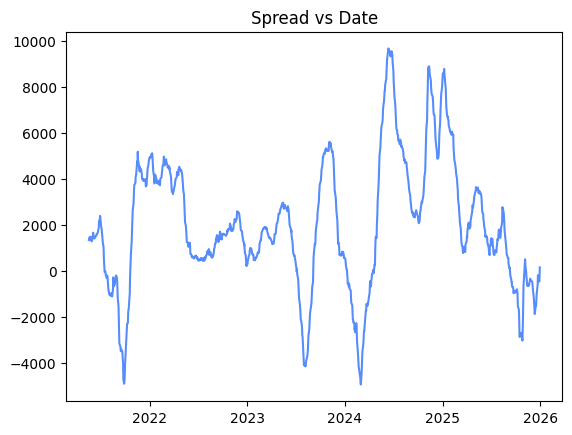

In [14]:
plt.plot(df['spread'])
plt.title('Spread vs Date')
plt.show()

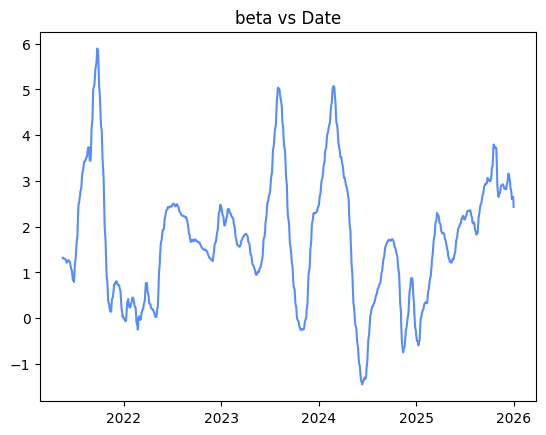

In [15]:
plt.plot(df['beta'])
plt.title('beta vs Date')
plt.show()
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(df['spread'].dropna())

t_stat = adf[0]
print("p-value :", adf[1])
crictical = adf[4]['10%']
print(t_stat < crictical)


p-value : 0.0030879709203724005
True


In [21]:
spread = df['spread'].dropna()

# yesterday's spread
lag = spread.shift(1)

# today's change
change = spread - lag

# remove NaNs
lag = lag.dropna()
change = change.dropna()

# align both
lag = lag.loc[change.index]

# regression: change ~ lag
beta = np.polyfit(lag, change, 1)[0]

# half-life
half_life = -np.log(2) / beta

print("Half-life:", half_life)

Half-life: 321.5741195460975
